# CS542 Final Project: Chest XRay Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


## EDA

Shape and Missing Values

In [2]:
MetaData = pd.read_csv('Chest_XRay+Data/Data_Entry_2017.csv')
MetaData.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [3]:
MetaData.shape
MetaData.nunique()
print(MetaData.isnull().sum())
MetaData = MetaData.drop(columns=["Unnamed: 11"])

Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position                       0
OriginalImage[Width                 0
Height]                             0
OriginalImagePixelSpacing[x         0
y]                                  0
Unnamed: 11                    112120
dtype: int64


No Missing values except "Unnamed: 11" which we are dropping as every point is missing and it is likely an empty artifact column.

In [4]:
# Remove patients with age over 100
MetaData = MetaData[MetaData["Patient Age"] <= 100]

# There were some errors in the age column, so we are deleting those rows that have a patient as over 100 years old. Now we can find the maximum age of the patients in the dataset.
print(MetaData["Patient Age"].max())

95


### Patient Patterns

Patient Scan Frequency and Unique Patients

In [5]:
# Total Number of Unique Patients
print("Total number of patients: ", MetaData['Patient ID'].nunique(), "\n")

# Identify patients with more than 1 scan instance
images_per_patient = MetaData.groupby("Patient ID").size() > 1

# Total number of patients with more than 1 scan instance
print("Patients with more than 1 scan instance: ", images_per_patient.sum(), "\n")
patients_with_multiple_images = images_per_patient[images_per_patient].index

# List the patients with more than 1 scan instance
print("Patients with more than 1 scan instance: ")
print(MetaData['Patient ID'].value_counts().loc[patients_with_multiple_images])


Total number of patients:  30802 

Patients with more than 1 scan instance:  13301 

Patients with more than 1 scan instance: 
Patient ID
1        3
3        8
5        8
8        3
11       9
        ..
30773    2
30786    8
30791    2
30792    2
30801    2
Name: count, Length: 13301, dtype: int64


While there are 112,000+ images, there are only 30,805 unqiue patients 13,302 of which have multiple scans in the dataset.

Patient Age Distribution

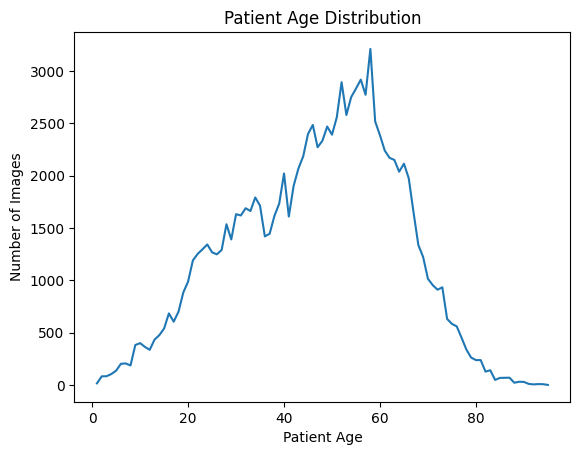

In [6]:


# Clean age column (ensure numeric)
MetaData["Patient Age"] = pd.to_numeric(MetaData["Patient Age"], errors="coerce")

# Drop missing ages
age_series = MetaData["Patient Age"].dropna()

# Count frequency of each age
age_counts = age_series.value_counts().sort_index()

# Plot as line plot
plt.figure()
plt.plot(age_counts.index, age_counts.values)
plt.xlabel("Patient Age")
plt.ylabel("Number of Images")
plt.title("Patient Age Distribution")
plt.show()

Patient Gender Breakdown

<Axes: xlabel='Patient Gender'>

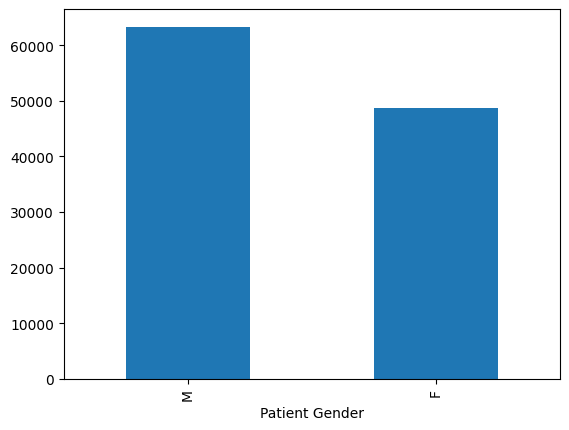

In [7]:
MetaData["Patient Gender"].value_counts()
MetaData["Patient Gender"].value_counts().plot(kind="bar")

There are ~15,000 more scans from Males than Females

View Position

In [8]:
MetaData["View Position"].value_counts()

View Position
PA    67299
AP    44805
Name: count, dtype: int64

In [9]:
labels = MetaData["Finding Labels"].str.get_dummies(sep="|")
pd.crosstab(MetaData["View Position"], labels["No Finding"], normalize="index")


No Finding,0,1
View Position,,
AP,0.530030,0.469970
PA,0.416098,0.583902


In [10]:
view_disease = pd.concat([MetaData["View Position"], labels], axis=1)
view_disease.groupby("View Position").mean()

,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
View Position,,,,,,,,,,,,,,,
AP,0.130142,0.027073,0.070215,0.045218,0.150139,0.022698,0.006205,0.000781,0.235264,0.049414,0.469970,0.048075,0.021560,0.017855,0.042294
PA,0.085098,0.023225,0.022601,0.004101,0.097906,0.022274,0.020922,0.002853,0.138932,0.052973,0.583902,0.062066,0.035929,0.009361,0.050610


We have 60% PA and 40% AP. Often AP is ore common in severe diseases, while PA is more common in normal cases. We could run into the issue that the model learns AP = disease instead of learning real pathology features. 

Based on if a disease was found we see that AP images have more disease cases and PA images have more normal cases. This does suggest a confounding risk of "If AP -> more likely disease" rather than learning actual pathology features. 

The disease-by-disease cases show theres a big increase in AP for Infiltration, a huge increase in AP for Edema, a big increase in AP for consolidation, and much more normal scans in PA. 

Essentially:
* Disease prevalence is not independent of view
* View position acts as a proxy for severity
* Have to look into controlling this for modeling

We could try stratifying the train/test split by View Position, train separate models for AP/PA, or include View Position as an input feature.

Disease Label Exploration

In [11]:
# Prevalence of each disease
labels = MetaData["Finding Labels"].str.get_dummies(sep="|")
labels.sum().sort_values(ascending=False)

No Finding            60353
Infiltration          19891
Effusion              13316
Atelectasis           11558
Nodule                 6331
Mass                   5779
Pneumothorax           5301
Consolidation          4667
Pleural_Thickening     3384
Cardiomegaly           2776
Emphysema              2516
Edema                  2302
Fibrosis               1686
Pneumonia              1430
Hernia                  227
dtype: int64

In [12]:
# How many image shave multiple diseases
labels.sum(axis=1).value_counts()

1    91312
2    14302
3     4856
4     1247
5      301
6       67
7       16
9        2
8        1
Name: count, dtype: int64

<Axes: >

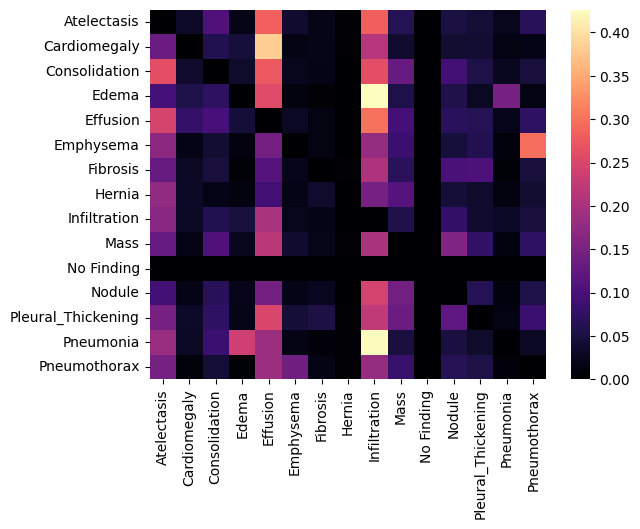

In [13]:
# Which diseases co-occur most frequently
co_matrix = labels.T.dot(labels)

# Normalize by row totals
co_matrix_norm = co_matrix.div(labels.sum(axis=0), axis=0)

np.fill_diagonal(co_matrix_norm.values, 0)

sns.heatmap(co_matrix_norm, cmap="magma")

Infiltration is the most common and Hernia is the least common.

Most images just have a singular disease, but a noticeable amiunt have 2-4.

The heatmap shows us some interesting correlations, with pneumonia and infiltration, Edema and Infiltration, and Effusion and Cardiomegaly all being more commonly found together than other combinations. The lighter columns on Atelectasis, Effusion and Infiltration suggest those can have a tendency to come with another disease. 

Follow-ups

In [14]:
MetaData["Follow-up #"].describe()
MetaData["Follow-up #"].value_counts().sort_index()

Follow-up #
0      30797
1      13301
2       9186
3       7088
4       5759
       ...  
179        1
180        1
181        1
182        1
183        1
Name: count, Length: 184, dtype: int64

There are few people with A LOT of follow-ups, but most don't follow-up.

Image Size & Pixel Spacing

In [16]:
MetaData[["OriginalImage[Width", "Height]"]].describe()

,OriginalImage[Width,Height]
count,112104.000000,112104.000000
mean,2646.035253,2486.393153
std,341.243771,401.270806
min,1143.000000,966.000000
25%,2500.000000,2048.000000
50%,2518.000000,2544.000000
75%,2992.000000,2991.000000
max,3827.000000,4715.000000


<Axes: >

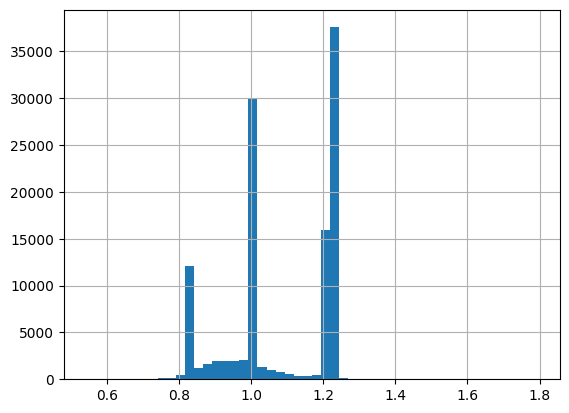

In [17]:
MetaData["Aspect_Ratio"] = (
    MetaData["OriginalImage[Width"] / MetaData["Height]"]
)

MetaData["Aspect_Ratio"].describe()
MetaData["Aspect_Ratio"].hist(bins=50)

These images (mean 2500x2500) are much larger than typical CNN images (224x224, 512x512) and the dataset is not uniform which matters as CNNs require a fixed input size. Some images are also not square, so cannot assume square inputs. So:
* Resize without preserving aspect ratio → distort anatomy
* Resize inconsistently → misalign bounding boxes
* Pad incorrectly → introduce artificial borders

The spect ratio graph shows us that there are clusters around 0.8, 1, and 1.2 indicating the images likely come from different scanners resolutions. This also means that most images are near square and it is likely these images were taken from different hospitals, machines, and acquisition protocols.

This is called data acquisition bias. 

Data Quality Checks

In [21]:

MetaData["Image Index"].duplicated().sum()
MetaData["Image Index"].isna().sum()

0

No missing or duplicated image entries